# ⏳ TP 3 : RNN et prévision d'une série temporelle

**Durée indicative : 2 h — Prérequis : tenseurs 3D et séparation temporelle.**

## Objectifs observables

1. transformer une série en fenêtres passé → valeur future ;
2. réserver une période future comme test ;
3. entraîner un `nn.RNN` avec le format `(batch, séquence, features)` ;
4. comparer le réseau à une baseline naïve ;
5. visualiser un cas contrôlé de gradient évanescent sans en faire une loi universelle.


## 1. Imports et Configuration


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print("Environnement PyTorch prêt !")


Environnement PyTorch prêt !


## 2. Synthèse d'une Série Temporelle Réaliste

Générons un signal combinant une composante harmonique périodique, une tendance lente et un bruit gaussien.


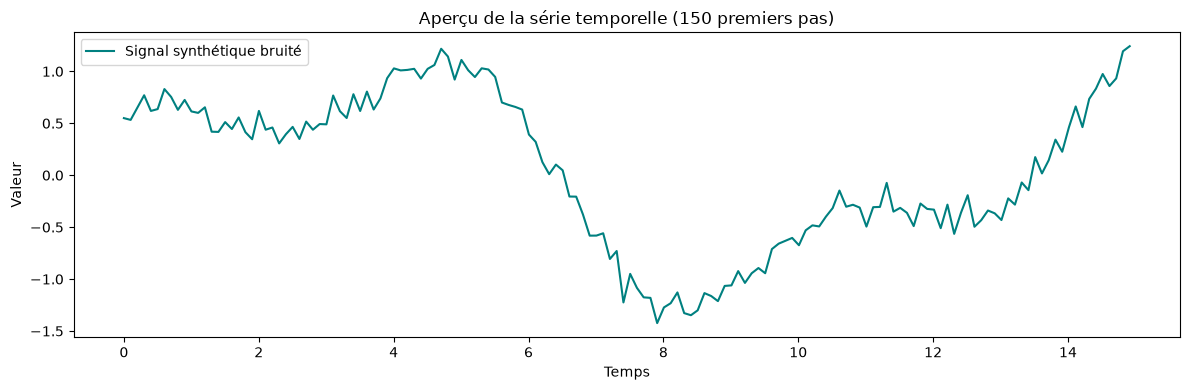

In [2]:
t = np.linspace(0, 100, 1000)
signal = np.sin(t * 0.5) + 0.5 * np.cos(t * 1.2) + 0.1 * np.random.randn(len(t))

plt.figure(figsize=(12, 4))
plt.plot(t[:150], signal[:150], label="Signal synthétique bruité", color='teal')
plt.title("Aperçu de la série temporelle (150 premiers pas)")
plt.xlabel("Temps")
plt.ylabel("Valeur")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Préparation des séquences avec fenêtre glissante

Pour prévoir la valeur suivante, chaque exemple contient les 25 observations précédentes.

> **Règle temporelle** : la coupure train/test respecte la chronologie. En revanche, mélanger les fenêtres **à l'intérieur du train** peut être acceptable pour une prévision supervisée à un pas, si le modèle ne transporte pas d'état caché d'un lot au suivant. Ce n'est pas équivalent à mélanger la série avant la coupure.


In [3]:
def create_sliding_windows(data, window_size=20):
    windows, targets = [], []
    for index in range(len(data) - window_size):
        windows.append(data[index:index + window_size])
        targets.append(data[index + window_size])
    return np.asarray(windows), np.asarray(targets)


window_size = 25
time_split = int(0.80 * len(signal))

# Le test commence au point time_split. On lui fournit seulement le contexte passé requis.
train_signal = signal[:time_split]
test_signal_with_context = signal[time_split - window_size:]
X_train, y_train = create_sliding_windows(train_signal, window_size)
X_test, y_test = create_sliding_windows(test_signal_with_context, window_size)

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

assert len(y_test) == len(signal) - time_split
assert np.isclose(y_test[0], signal[time_split])
print("X_train :", tuple(X_train_t.shape))
print("X_test  :", tuple(X_test_t.shape))
print("Première cible du test = signal au point de coupure : contrôle réussi.")


X_train : (775, 25, 1)
X_test  : (200, 25, 1)
Première cible du test = signal au point de coupure : contrôle réussi.


## 4. Construction de l'Architecture Vanilla RNN

> 📐 **Comprendre le Tenseur 3D Récurrent `(Batch, Seq_Len, Features)`** :
> Contrairement à un tableur 2D, PyTorch attend pour les RNN un tenseur à 3 axes :
> - `Batch` : Nombre de séquences traitées en même temps (ex: 32).
> - `Seq_Len` : Nombre de pas de temps dans la séquence (ici 20 jours).
> - `Features` : Nombre de mesures prises à chaque pas (ici 1 seule mesure : la température).
>
> L'option `batch_first=True` permet d'avoir la taille du batch en première position, ce qui est beaucoup plus intuitif.

In [4]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        # nn.RNN avec batch_first=True prend des tenseurs (Batch, Seq_len, Features)
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # out contient les états cachés pour tous les pas temporels: (Batch, Seq_len, Hidden)
        # h_n contient le dernier état caché: (1, Batch, Hidden)
        out, h_n = self.rnn(x)
        # On utilise le dernier état caché pour la prédiction finale
        last_step_out = out[:, -1, :]
        prediction = self.fc(last_step_out)
        return prediction

model_rnn = VanillaRNN(input_size=1, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_rnn.parameters(), lr=0.01)
print(model_rnn)


VanillaRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 5. Entraînement du Modèle


In [5]:
epochs = 120
losses = []

for epoch in range(epochs):
    model_rnn.train()
    optimizer.zero_grad()
    predictions = model_rnn(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Époque [{epoch+1}/{epochs}] - Perte MSE : {loss.item():.5f}")


Époque [20/120] - Perte MSE : 0.03378
Époque [40/120] - Perte MSE : 0.02149


Époque [60/120] - Perte MSE : 0.01841
Époque [80/120] - Perte MSE : 0.01685


Époque [100/120] - Perte MSE : 0.01622
Époque [120/120] - Perte MSE : 0.01578


## 6. Évaluation et Visualisation des Prédictions


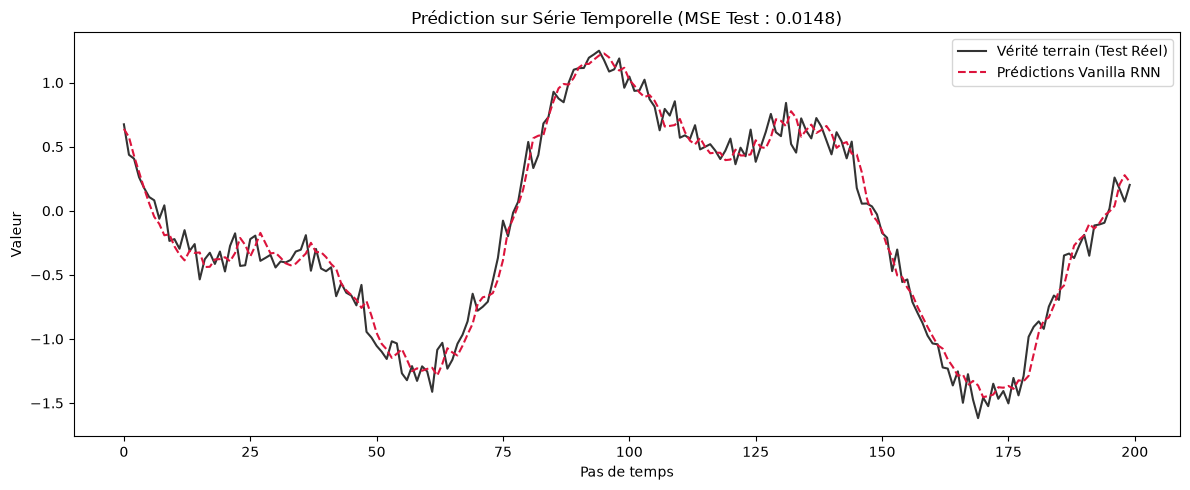

In [6]:
model_rnn.eval()
with torch.no_grad():
    y_pred_test = model_rnn(X_test_t).squeeze().numpy()

plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Vérité terrain (Test Réel)", color='black', alpha=0.8)
plt.plot(y_pred_test, label="Prédictions Vanilla RNN", color='crimson', linestyle='--')
plt.title(f"Prédiction sur Série Temporelle (MSE Test : {np.mean((y_pred_test - y_test)**2):.4f})")
plt.xlabel("Pas de temps")
plt.ylabel("Valeur")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Le Problème du Vanishing Gradient (Disparition du Gradient)

Quand la taille de la séquence $W$ grandit, la dérivée $\frac{\partial h_t}{\partial h_1}$ implique de multiplier $W$ fois la matrice des poids récurrents $W_{hh}$.

Mesurons la magnitude du gradient des premiers pas de temps par rapport aux derniers pas lorsque la séquence devient longue :


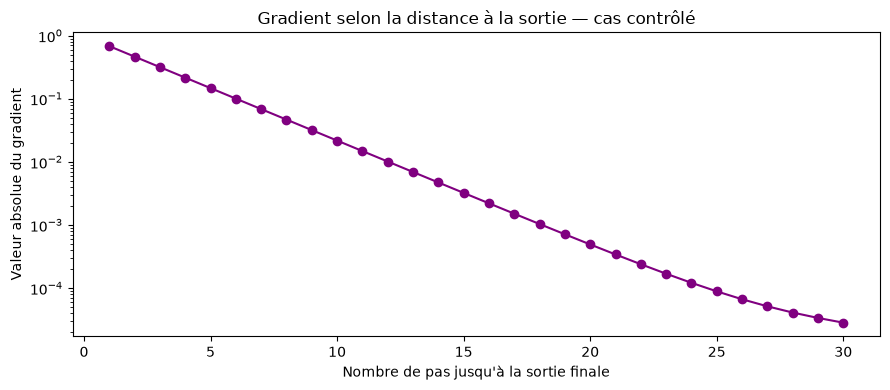

In [7]:
# Cas contrôlé : poids récurrent < 1 et biais nuls.
rnn_cell = nn.RNNCell(input_size=1, hidden_size=1)
with torch.no_grad():
    rnn_cell.weight_hh.fill_(0.85)
    rnn_cell.weight_ih.fill_(1.0)
    rnn_cell.bias_hh.zero_()
    rnn_cell.bias_ih.zero_()

hidden = torch.tensor([[0.0]], requires_grad=True)
states = [hidden]
sequence_length = 30

for _ in range(sequence_length):
    current_input = torch.tensor([[0.1]])
    hidden = rnn_cell(current_input, hidden)
    states.append(hidden)

final_state = states[-1].sum()
gradient_magnitudes = [
    abs(torch.autograd.grad(final_state, state, retain_graph=True)[0].item())
    for state in states[:-1]
]
temporal_distance = np.arange(sequence_length, 0, -1)

plt.figure(figsize=(9, 4))
plt.plot(temporal_distance, gradient_magnitudes, 'o-', color='purple')
plt.title("Gradient selon la distance à la sortie — cas contrôlé")
plt.xlabel("Nombre de pas jusqu'à la sortie finale")
plt.ylabel("Valeur absolue du gradient")
plt.yscale('log')
plt.tight_layout()
plt.show()

assert gradient_magnitudes[0] < gradient_magnitudes[-1]


Dans ce montage volontairement choisi avec un poids récurrent inférieur à 1, le gradient décroît quand la distance temporelle augmente. Un autre réglage peut produire une décroissance plus lente ou au contraire une explosion : le phénomène dépend des poids, des activations et des entrées.


## 8. Exercice guidé : comparer une baseline naïve

Une baseline de persistance prédit que la prochaine valeur sera égale à la dernière valeur observée dans la fenêtre. Calculez sa MSE sur exactement les mêmes cibles que le RNN.

**Critère de réussite** : rapportez les deux MSE, même si le réseau ne bat pas la baseline. Cette comparaison est plus informative qu'un graphique isolé.


In [8]:
# À vous de jouer.
# TODO : extraire la dernière valeur de chaque fenêtre de test et calculer sa MSE.


In [9]:
naive_predictions = X_test[:, -1]
mse_naive = np.mean((naive_predictions - y_test) ** 2)
mse_rnn = np.mean((y_pred_test - y_test) ** 2)

print(f"MSE baseline de persistance : {mse_naive:.5f}")
print(f"MSE Vanilla RNN             : {mse_rnn:.5f}")
if mse_rnn < mse_naive:
    print("Sur cette exécution, le RNN améliore la baseline.")
else:
    print("Sur cette exécution, la baseline reste meilleure : le modèle doit être revu.")

assert np.isfinite([mse_naive, mse_rnn]).all()


MSE baseline de persistance : 0.02068
MSE Vanilla RNN             : 0.01482
Sur cette exécution, le RNN améliore la baseline.


## Conclusion et auto-évaluation

1. La coupure chronologique porte sur la série ; le test peut utiliser un contexte passé sans utiliser de cible future.
2. Le format d'entrée du RNN est `(batch, séquence, features)` avec `batch_first=True`.
3. Toute architecture doit être comparée à une baseline adaptée.
4. Le gradient évanescent est une dynamique possible, pas un seuil fixe valable pour tous les RNN.
